In [78]:
import pandas as pd
import seaborn as sns
from scipy.stats import trim_mean

In [4]:
db = pd.read_csv("bikeshare-ridership-2026.csv")

In [5]:
db.head()

,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model
0,43682415,248,7719,2026-01-01 00:00:26,Wolseley St / Augusta Ave,7037.0,2026-01-01 00:04:34,Bathurst St / Dundas St W,122,Member,ICONIC
1,43682417,295,8001,2026-01-01 00:02:05,Union Station (North),7076.0,2026-01-01 00:07:00,York St / Queens Quay W,4900,Member,ICONIC
2,43682418,2701,7172,2026-01-01 00:04:15,Strachan Ave / Princes' Blvd,7100.0,2026-01-01 00:49:16,Dundas St E / Regent Park Blvd,1833,Member,ICONIC
3,43682419,581,7259,2026-01-01 00:04:29,Lower Spadina Ave / Lake Shore Blvd W,7076.0,2026-01-01 00:14:10,York St / Queens Quay W,5078,Casual,ICONIC
4,43682420,600,7259,2026-01-01 00:04:53,Lower Spadina Ave / Lake Shore Blvd W,7076.0,2026-01-01 00:14:53,York St / Queens Quay W,3951,Member,ICONIC


In [6]:
 db.shape

(552073, 11)

In [7]:
db.columns

Index(['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time',
       'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name',
       'Bike_Id', 'User_Type', 'Bike_Model'],
      dtype='object')

In [8]:
db.describe()
# Average trip duration being around 12-13 minutes long

,Trip_Id,Trip_Duration,Start_Station_Id,End_Station_Id,Bike_Id
count,5.520730e+05,552073.000000,552073.000000,550590.000000,552073.000000
mean,4.400137e+07,734.188183,7405.595985,7404.442847,5378.452781
std,1.832947e+05,975.712597,330.728170,332.262269,3201.724941
min,4.368242e+07,0.000000,7000.000000,7000.000000,14.000000
25%,4.384135e+07,372.000000,7114.000000,7110.000000,2672.000000
50%,4.400318e+07,581.000000,7316.000000,7311.000000,5154.000000
75%,4.416191e+07,899.000000,7682.000000,7682.000000,8676.000000
max,4.431391e+07,207334.000000,8227.000000,8227.000000,10948.000000


<Axes: xlabel='Trip_Duration', ylabel='Count'>

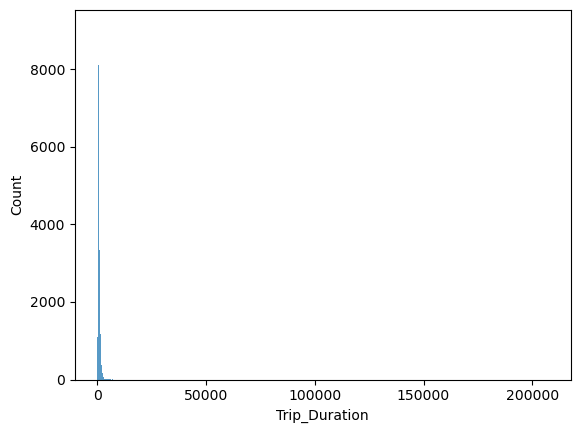

In [9]:
# Utilizing a histogram to visualize the distribution of the trip duration
sns.histplot(db['Trip_Duration'])
# X axis is extending to around 200000 seconds, meaning that there are some high outliers that my interfere with the later exploration, so i'll
# keep this in mind

In [10]:
# checking the amount of members
num_members = db['User_Type'].loc[db['User_Type'] == 'Member'].count()
total_users = len(db)

# turning it into a percentage, to around 2 decimal places

print(round(num_members/total_users * 100, 2), ' % of total members in the 2026 database')

88.92  % of total members in the 2026 database


# Q1: What are the stations with the highest inflow and outflow during peak hours (7-11 Am) (4-7 PM)
The purpose of analyzing this information is to determine which stations have a positive or negative net flow to identify stations with an imbalance between supply and demand.

In [11]:
db.dtypes

Trip_Id                 int64
Trip_Duration           int64
Start_Station_Id        int64
Start_Time             object
Start_Station_Name     object
End_Station_Id        float64
End_Time               object
End_Station_Name       object
Bike_Id                 int64
User_Type              object
Bike_Model             object
dtype: object

In [12]:
db["Start_Time"].dtype

dtype('O')

In [13]:
db["Start_Time"] = pd.to_datetime(db["Start_Time"])
db["End_Time"] = pd.to_datetime(db["End_Time"])

db["Start_Hour"] = db["Start_Time"].dt.hour
db["End_Hour"] = db["End_Time"].dt.hour



In [14]:
db["Start_Time"].dtype
db

,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Bike_Model,Start_Hour,End_Hour
0,43682415,248,7719,2026-01-01 00:00:26,Wolseley St / Augusta Ave,7037.0,2026-01-01 00:04:34,Bathurst St / Dundas St W,122,Member,ICONIC,0,0.0
1,43682417,295,8001,2026-01-01 00:02:05,Union Station (North),7076.0,2026-01-01 00:07:00,York St / Queens Quay W,4900,Member,ICONIC,0,0.0
2,43682418,2701,7172,2026-01-01 00:04:15,Strachan Ave / Princes' Blvd,7100.0,2026-01-01 00:49:16,Dundas St E / Regent Park Blvd,1833,Member,ICONIC,0,0.0
3,43682419,581,7259,2026-01-01 00:04:29,Lower Spadina Ave / Lake Shore Blvd W,7076.0,2026-01-01 00:14:10,York St / Queens Quay W,5078,Casual,ICONIC,0,0.0
4,43682420,600,7259,2026-01-01 00:04:53,Lower Spadina Ave / Lake Shore Blvd W,7076.0,2026-01-01 00:14:53,York St / Queens Quay W,3951,Member,ICONIC,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
552068,44313907,94,7270,2026-03-31 23:57:22,Church St / Dundas St E - SMART,7121.0,2026-03-31 23:58:56,Jarvis St / Dundas St E,7538,Member,EFIT,23,23.0
552069,44313908,1575,7323,2026-03-31 23:58:17,457 King St W,7666.0,2026-04-01 00:24:32,Dundas St W / St Helen's Ave - SMART,10464,Member,ICONIC,23,0.0
552070,44313910,381,7324,2026-03-31 23:58:41,King St W / Charlotte St,7000.0,2026-04-01 00:05:02,Fort York Blvd / Capreol Ct,9180,Casual,ICONIC,23,0.0
552071,44313911,1446,7822,2026-03-31 23:59:30,Leslie St / Commissioners St,7175.0,2026-04-01 00:23:36,HTO Park (Queens Quay W),1733,Member,ICONIC,23,0.0


In [15]:
#General Rush hour activity, versus purely checkouts done in peak hours and returns done in rush hour

rush_any = db[
    db['Start_Hour'].between(7,11) |
    db['Start_Hour'].between(16,19) |
    db['End_Hour'].between(7,11) |
    db['End_Hour'].between(16,19)
]


rush_checkouts = db[
    db['Start_Hour'].between(7,11) |
    db['Start_Hour'].between(16,19)
]

rush_returns = db[
    db['End_Hour'].between(7,11) |
    db['End_Hour'].between(16,19)
]

In [16]:
# now that the dataframe for the peak hours is done, we can split it into inflow nad outflow

In [17]:
outflow = (rush_checkouts
           .groupby(['Start_Station_Id', 'Start_Station_Name'])
           .size() #Size will give me the count for each group
           .reset_index(name='Checkouts'))

In [18]:
inflow = (rush_returns
          .groupby(['End_Station_Id', 'End_Station_Name'])
          .size()
          .reset_index(name= 'Returns'))

In [19]:
# creating a join for the all of the stations that are part of the net flow for these time frames

stations_net = pd.merge(
    outflow,
    inflow,
    left_on = 'Start_Station_Id',
    right_on = 'End_Station_Id',
    how= 'outer'
)


    


In [20]:
outflow

,Start_Station_Id,Start_Station_Name,Checkouts
0,7000,Fort York Blvd / Capreol Ct,1525
1,7001,Wellesley Station Green P,1235
2,7002,St. George St / Bloor St W,1823
3,7003,Madison Ave / Bloor St W,325
4,7005,King St W / York St,324
...,...,...,...
992,8219,Kennedy Station,4
993,8222,NycLab,1
994,8224,439 Wellington St W,309
995,8226,O'Connor Dr / Dohme Ave,1


In [21]:
only_outflow = stations_net[stations_net["Returns"].isna()]

In [22]:
only_inflow = stations_net[stations_net["Checkouts"].isna()]

In [23]:
only_outflow

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns
662,7807.0,552 Birchmount Rd,1.0,NaN,NaN,NaN
690,7837.0,Ling Rd / Morningside Ave,1.0,NaN,NaN,NaN
711,7859.0,Mallaby Park,1.0,NaN,NaN,NaN
720,7868.0,Sheppard Ave W / Chesswood Dr,2.0,NaN,NaN,NaN
799,7956.0,Benshire Dr / The Meadoway,1.0,NaN,NaN,NaN
850,8010.0,Finch Ave W / Bathurst St,2.0,NaN,NaN,NaN
867,8033.0,Ridge Rd / Wilson Ave,3.0,NaN,NaN,NaN
880,8049.0,YZD,2.0,NaN,NaN,NaN
883,8052.0,Warden Ave / The Meadoway,2.0,NaN,NaN,NaN
894,8063.0,Maida Vale Park,1.0,NaN,NaN,NaN


In [24]:
# just from viewing this, there seem to be some stations that only have leaves but no returns, or returns but is not in use, which could be undocumented trips
# or excess bikes being left at full stations.
# however now that we got a look at the leaves and returns from stations, lets take a look at the net-flow of the stations in total
# lets head back to cleaning up the outflow and inflow charts first before creating the netflow



In [25]:

stations_net["Station_Id"] = stations_net["Start_Station_Id"].combine_first(stations_net["End_Station_Id"])
stations_net["Station_Name"] = stations_net["Start_Station_Name"].combine_first(stations_net["End_Station_Name"])

stations_net["Checkouts"] = stations_net["Checkouts"].fillna(0)
stations_net["Returns"] = stations_net["Returns"].fillna(0)



In [26]:
stations_net

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name
0,7000.0,Fort York Blvd / Capreol Ct,1525.0,7000.0,Fort York Blvd / Capreol Ct,1162.0,7000.0,Fort York Blvd / Capreol Ct
1,7001.0,Wellesley Station Green P,1235.0,7001.0,Wellesley Station Green P,1256.0,7001.0,Wellesley Station Green P
2,7002.0,St. George St / Bloor St W,1823.0,7002.0,St. George St / Bloor St W,1906.0,7002.0,St. George St / Bloor St W
3,7003.0,Madison Ave / Bloor St W,325.0,7003.0,Madison Ave / Bloor St W,341.0,7003.0,Madison Ave / Bloor St W
4,7005.0,King St W / York St,324.0,7005.0,King St W / York St,441.0,7005.0,King St W / York St
...,...,...,...,...,...,...,...,...
1009,8219.0,Kennedy Station,4.0,8219.0,Kennedy Station,3.0,8219.0,Kennedy Station
1010,8222.0,NycLab,1.0,8222.0,NycLab,3.0,8222.0,NycLab
1011,8224.0,439 Wellington St W,309.0,8224.0,439 Wellington St W,327.0,8224.0,439 Wellington St W
1012,8226.0,O'Connor Dr / Dohme Ave,1.0,8226.0,O'Connor Dr / Dohme Ave,3.0,8226.0,O'Connor Dr / Dohme Ave


In [27]:
stations_net["Net_flow"] = stations_net["Checkouts"] - stations_net["Returns"]

In [28]:
stations_net

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name,Net_flow
0,7000.0,Fort York Blvd / Capreol Ct,1525.0,7000.0,Fort York Blvd / Capreol Ct,1162.0,7000.0,Fort York Blvd / Capreol Ct,363.0
1,7001.0,Wellesley Station Green P,1235.0,7001.0,Wellesley Station Green P,1256.0,7001.0,Wellesley Station Green P,-21.0
2,7002.0,St. George St / Bloor St W,1823.0,7002.0,St. George St / Bloor St W,1906.0,7002.0,St. George St / Bloor St W,-83.0
3,7003.0,Madison Ave / Bloor St W,325.0,7003.0,Madison Ave / Bloor St W,341.0,7003.0,Madison Ave / Bloor St W,-16.0
4,7005.0,King St W / York St,324.0,7005.0,King St W / York St,441.0,7005.0,King St W / York St,-117.0
...,...,...,...,...,...,...,...,...,...
1009,8219.0,Kennedy Station,4.0,8219.0,Kennedy Station,3.0,8219.0,Kennedy Station,1.0
1010,8222.0,NycLab,1.0,8222.0,NycLab,3.0,8222.0,NycLab,-2.0
1011,8224.0,439 Wellington St W,309.0,8224.0,439 Wellington St W,327.0,8224.0,439 Wellington St W,-18.0
1012,8226.0,O'Connor Dr / Dohme Ave,1.0,8226.0,O'Connor Dr / Dohme Ave,3.0,8226.0,O'Connor Dr / Dohme Ave,-2.0


now we can get a look for the top stations which have a positive netflow (Meaning more leaves than returns) and a negative net flow (more returns than leaves)


In [29]:
# Higher Positive means more leaves than returns

top10_outflow = stations_net.sort_values("Net_flow", ascending = False).head(10)

top10_inflow = stations_net.sort_values("Net_flow").head(10)


## Viewing The Top 10 Outflow

In [30]:
top10_outflow

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name,Net_flow
26,7030.0,Bay St / Wellesley St W,2294.0,7030.0,Bay St / Wellesley St W,1405.0,7030.0,Bay St / Wellesley St W,889.0
235,7281.0,Charles St W / Balmuto St - SMART,1718.0,7281.0,Charles St W / Balmuto St - SMART,885.0,7281.0,Charles St W / Balmuto St - SMART,833.0
334,7409.0,Isabella St / Church St,1492.0,7409.0,Isabella St / Church St,714.0,7409.0,Isabella St / Church St,778.0
21,7025.0,Ted Rogers Way / Bloor St E,1388.0,7025.0,Ted Rogers Way / Bloor St E,619.0,7025.0,Ted Rogers Way / Bloor St E,769.0
38,7042.0,Sherbourne St / Wellesley St E,1461.0,7042.0,Sherbourne St / Wellesley St E,758.0,7042.0,Sherbourne St / Wellesley St E,703.0
40,7044.0,Church St / Alexander St,1403.0,7044.0,Church St / Alexander St,832.0,7044.0,Church St / Alexander St,571.0
20,7024.0,Dundonald St / Church St,756.0,7024.0,Dundonald St / Church St,255.0,7024.0,Dundonald St / Church St,501.0
76,7089.0,Church St / Wood St,1706.0,7089.0,Church St / Wood St,1214.0,7089.0,Church St / Wood St,492.0
369,7452.0,Bleecker St / St James Ave,790.0,7452.0,Bleecker St / St James Ave,383.0,7452.0,Bleecker St / St James Ave,407.0
100,7115.0,Howard St / Sherbourne St,849.0,7115.0,Howard St / Sherbourne St,454.0,7115.0,Howard St / Sherbourne St,395.0


## Viewing The Top 10 Inflow

In [31]:
top10_inflow

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name,Net_flow
12,7015.0,King St W / Bay St (West Side),1804.0,7015.0,King St W / Bay St (West Side),5130.0,7015.0,King St W / Bay St (West Side),-3326.0
16,7019.0,Temperance St Station,2057.0,7019.0,Temperance St Station,4050.0,7019.0,Temperance St Station,-1993.0
237,7283.0,Front St W / Bay St (South Side),1086.0,7283.0,Front St W / Bay St (South Side),2715.0,7283.0,Front St W / Bay St (South Side),-1629.0
43,7047.0,University Ave / Gerrard St W (East Side),1824.0,7047.0,University Ave / Gerrard St W (East Side),2644.0,7047.0,University Ave / Gerrard St W (East Side),-820.0
537,7660.0,285 Victoria St,569.0,7660.0,285 Victoria St,877.0,7660.0,285 Victoria St,-308.0
34,7038.0,Dundas St W / Yonge St,1244.0,7038.0,Dundas St W / Yonge St,1530.0,7038.0,Dundas St W / Yonge St,-286.0
66,7076.0,York St / Queens Quay W,1559.0,7076.0,York St / Queens Quay W,1812.0,7076.0,York St / Queens Quay W,-253.0
15,7018.0,Bremner Blvd / Rees St,702.0,7018.0,Bremner Blvd / Rees St,952.0,7018.0,Bremner Blvd / Rees St,-250.0
437,7542.0,Queen St W / John St,1778.0,7542.0,Queen St W / John St,2017.0,7542.0,Queen St W / John St,-239.0
211,7250.0,Ursula Franklin St / St. George St - SMART,1149.0,7250.0,Ursula Franklin St / St. George St - SMART,1373.0,7250.0,Ursula Franklin St / St. George St - SMART,-224.0


## The average Net_flow

In [89]:
# Trimming some of the more extreme values to get a more accurate depiction of the main mass of data
trim_mean(stations_net['Net_flow'], proportiontocut=0.1)

2.6945812807881775

# Analysis of Question 1 (Inflow)


From what can be observed, Plenty stations in the downtown core have a high inflow and outflow, as expected. However, there is a vast difference between the highest outflow imbalance and the highest inflow imbalance, of approximately 2000. From this information, the King St W / Bay St station has more than twice as many returns as it does checkouts. This would lead this station to be a high traffic area for bikers to drop off, meaning that this station should be relatively full of bikes most of the time and may experience an excess of bikes being parked. However, this would need to be determined by how many users are requesting extra time to relocate their bikes to another station to park.

## Is this a concern?

Suppose there is an issue at this particular station. An excess inflow of bikes during peak hours could lead to customer frustration due to common commuter time constraints within this time period, due to the station being within the central business district of Toronto/ downtown core. This would also, in theory, create a problematic bottleneck during peak hours within the downtown core due to just how high the inflow difference is. This could imply the need for infrastructure expansion if the program is generating exceedingly more revenue than the costs to run it.

In this case, this information would signal that this location should have more bike charging/holding stations than the others due to the larger net inflow. If this is the case and has already been addressed beforehand, then not much else needs to be done. However if this is a recently growing boom in the use of the bike share program in general then this station would need to be adjusted. The required adjustments however cannot be determined by this data alone, we would need access to how many times customers have to request extra time to relocate to accurately decide if the issue is of concern.

# Analysis of Question 1 Continued (Outflow)

Moving on to analyzing the outflow, we can see that the outflow values aren't as extreme as the inflow. This demonstrates that trip starting points are more geographically spread out, while the destinations are concentrated. This data would make sense due to the nature of the area where the majority of the analyzed stations reside - within the downtown core. 

While looking at the data, it can be noted that there are a larger number of stations with a moderately high net_outflow. This would indicate a slow, but widespread depletion of bikes within the program. This can also be further reflected in unmet demands if users complain about such issues.

However, due to the analysis simply being limited to peak hours, the numbers are definitely amplified compared to the average usage. So, due to this analysis being focused on peak hours, no definite conclusions can be made, just simple questions that can lead to deeper dives into the data.

In [33]:
top20_outflow = stations_net.sort_values("Net_flow", ascending = False).head(20)

In [34]:
top20_outflow

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name,Net_flow
26,7030.0,Bay St / Wellesley St W,2294.0,7030.0,Bay St / Wellesley St W,1405.0,7030.0,Bay St / Wellesley St W,889.0
235,7281.0,Charles St W / Balmuto St - SMART,1718.0,7281.0,Charles St W / Balmuto St - SMART,885.0,7281.0,Charles St W / Balmuto St - SMART,833.0
334,7409.0,Isabella St / Church St,1492.0,7409.0,Isabella St / Church St,714.0,7409.0,Isabella St / Church St,778.0
21,7025.0,Ted Rogers Way / Bloor St E,1388.0,7025.0,Ted Rogers Way / Bloor St E,619.0,7025.0,Ted Rogers Way / Bloor St E,769.0
38,7042.0,Sherbourne St / Wellesley St E,1461.0,7042.0,Sherbourne St / Wellesley St E,758.0,7042.0,Sherbourne St / Wellesley St E,703.0
40,7044.0,Church St / Alexander St,1403.0,7044.0,Church St / Alexander St,832.0,7044.0,Church St / Alexander St,571.0
20,7024.0,Dundonald St / Church St,756.0,7024.0,Dundonald St / Church St,255.0,7024.0,Dundonald St / Church St,501.0
76,7089.0,Church St / Wood St,1706.0,7089.0,Church St / Wood St,1214.0,7089.0,Church St / Wood St,492.0
369,7452.0,Bleecker St / St James Ave,790.0,7452.0,Bleecker St / St James Ave,383.0,7452.0,Bleecker St / St James Ave,407.0
100,7115.0,Howard St / Sherbourne St,849.0,7115.0,Howard St / Sherbourne St,454.0,7115.0,Howard St / Sherbourne St,395.0


### Extra Charts for Reference
General Net_Flow For all hours

In [35]:
outflow_all = (db
           .groupby(['Start_Station_Id', 'Start_Station_Name',])
           .size() #Size will give me the count for each group
           .reset_index(name='Checkouts'))

In [36]:
inflow_all= (db
           .groupby(['End_Station_Id', 'End_Station_Name',])
           .size() #Size will give me the count for each group
           .reset_index(name='Returns'))

In [37]:
all_stations_net = pd.merge(
    outflow_all,
    inflow_all,
    left_on = 'Start_Station_Id',
    right_on = 'End_Station_Id',
    how= 'outer'
)

all_stations_net["Station_Id"] = all_stations_net["Start_Station_Id"].combine_first(all_stations_net["End_Station_Id"])
all_stations_net["Station_Name"] = all_stations_net["Start_Station_Name"].combine_first(all_stations_net["End_Station_Name"])

all_stations_net["Checkouts"] = all_stations_net["Checkouts"].fillna(0)
all_stations_net["Returns"] = all_stations_net["Returns"].fillna(0)

all_stations_net["Net_flow"] = all_stations_net["Checkouts"] - all_stations_net["Returns"]



In [38]:
all_stations_net["Station_Name"] = all_stations_net["Start_Station_Name"].combine_first(all_stations_net["End_Station_Name"])

all_stations_net = all_stations_net.drop(columns=['Start_Station_Name', 'End_Station_Name', 'Start_Station_Id', 'End_Station_Id'])

all_stations_net


,Checkouts,Returns,Station_Id,Station_Name,Net_flow
0,2211.0,2037.0,7000.0,Fort York Blvd / Capreol Ct,174.0
1,2191.0,2167.0,7001.0,Wellesley Station Green P,24.0
2,3100.0,3102.0,7002.0,St. George St / Bloor St W,-2.0
3,766.0,765.0,7003.0,Madison Ave / Bloor St W,1.0
4,481.0,516.0,7005.0,King St W / York St,-35.0
...,...,...,...,...,...
1021,2.0,0.0,8221.0,Ling Rd / Lawrence Ave E,2.0
1022,5.0,5.0,8222.0,NycLab,0.0
1023,479.0,493.0,8224.0,439 Wellington St W,-14.0
1024,3.0,5.0,8226.0,O'Connor Dr / Dohme Ave,-2.0


In [39]:

top10_all_outflow = all_stations_net.sort_values("Net_flow", ascending = False).head(10)

top10_all_inflow = all_stations_net.sort_values("Net_flow").head(10)

In [40]:
top10_all_outflow

,Checkouts,Returns,Station_Id,Station_Name,Net_flow
235,2996.0,1625.0,7281.0,Charles St W / Balmuto St - SMART,1371.0
26,3816.0,2499.0,7030.0,Bay St / Wellesley St W,1317.0
40,2828.0,1592.0,7044.0,Church St / Alexander St,1236.0
334,2550.0,1357.0,7409.0,Isabella St / Church St,1193.0
21,2213.0,1064.0,7025.0,Ted Rogers Way / Bloor St E,1149.0
38,2482.0,1469.0,7042.0,Sherbourne St / Wellesley St E,1013.0
20,1251.0,490.0,7024.0,Dundonald St / Church St,761.0
201,2326.0,1689.0,7239.0,Bloor St W / Manning Ave - SMART,637.0
100,1476.0,868.0,7115.0,Howard St / Sherbourne St,608.0
76,2952.0,2354.0,7089.0,Church St / Wood St,598.0


In [41]:
top10_all_inflow

,Checkouts,Returns,Station_Id,Station_Name,Net_flow
12,2340.0,5707.0,7015.0,King St W / Bay St (West Side),-3367.0
16,2770.0,4703.0,7019.0,Temperance St Station,-1933.0
237,1699.0,3631.0,7283.0,Front St W / Bay St (South Side),-1932.0
43,2777.0,3554.0,7047.0,University Ave / Gerrard St W (East Side),-777.0
88,2055.0,2470.0,7102.0,Nelson St / Duncan St,-415.0
352,2612.0,2987.0,7432.0,Frederick St / King St E,-375.0
66,2528.0,2867.0,7076.0,York St / Queens Quay W,-339.0
87,1085.0,1422.0,7101.0,Lower Sherbourne St / The Esplanade,-337.0
44,966.0,1278.0,7048.0,Front St W / Yonge St (Hockey Hall of Fame),-312.0
144,884.0,1192.0,7168.0,Queens Quay / Yonge St,-308.0


# Extra Analysis for Language/Syntax Practice
## Observing Other Peak Hours that Don't maintain the same netflow with a smaller sample size

From comparing the stations during peak hours to their general net_flow, we can see that the Top 2 stations for Inflow and Outflow stay in the same position. However, the net_flow increases for the top 2 outflow stations outside of the viewed peak hours so lets take the chance to view the difference. These would be 7281 and 7030

In [180]:
top2_outflow = all_stations_net.sort_values("Net_flow", ascending = False).head(2)
top2_outflow

,Checkouts,Returns,Station_Id,Station_Name,Net_flow
235,2996.0,1625.0,7281.0,Charles St W / Balmuto St - SMART,1371.0
26,3816.0,2499.0,7030.0,Bay St / Wellesley St W,1317.0


In [181]:
top2_outflow_peak = stations_net.sort_values("Net_flow", ascending = False).head(2)
top2_outflow_peak

,Start_Station_Id,Start_Station_Name,Checkouts,End_Station_Id,End_Station_Name,Returns,Station_Id,Station_Name,Net_flow
26,7030.0,Bay St / Wellesley St W,2294.0,7030.0,Bay St / Wellesley St W,1405.0,7030.0,Bay St / Wellesley St W,889.0
235,7281.0,Charles St W / Balmuto St - SMART,1718.0,7281.0,Charles St W / Balmuto St - SMART,885.0,7281.0,Charles St W / Balmuto St - SMART,833.0


In [182]:
#Getting all general outflow and inflow without the suggested peak hours as a groupby clause

outflow_observed = (db
           .groupby(['Start_Station_Id', 'Start_Station_Name', 'Start_Hour'])
           .size() #Size will give me the count for each group
           .reset_index(name='Checkouts'))

inflow_observed = (db
           .groupby(['End_Station_Id', 'End_Station_Name', 'End_Hour'])
           .size() #Size will give me the count for each group
           .reset_index(name='Returns'))

In [183]:
outflow_observed

,Start_Station_Id,Start_Station_Name,Start_Hour,Checkouts
0,7000,Fort York Blvd / Capreol Ct,0,7
1,7000,Fort York Blvd / Capreol Ct,1,3
2,7000,Fort York Blvd / Capreol Ct,2,1
3,7000,Fort York Blvd / Capreol Ct,4,9
4,7000,Fort York Blvd / Capreol Ct,5,13
...,...,...,...,...
17360,8224,439 Wellington St W,23,7
17361,8226,O'Connor Dr / Dohme Ave,16,1
17362,8226,O'Connor Dr / Dohme Ave,20,1
17363,8226,O'Connor Dr / Dohme Ave,21,1


In [184]:
inflow_observed


,End_Station_Id,End_Station_Name,End_Hour,Returns
0,7000.0,Fort York Blvd / Capreol Ct,0.0,28
1,7000.0,Fort York Blvd / Capreol Ct,1.0,10
2,7000.0,Fort York Blvd / Capreol Ct,2.0,8
3,7000.0,Fort York Blvd / Capreol Ct,3.0,4
4,7000.0,Fort York Blvd / Capreol Ct,4.0,3
...,...,...,...,...
17276,8226.0,O'Connor Dr / Dohme Ave,5.0,2
17277,8226.0,O'Connor Dr / Dohme Ave,9.0,1
17278,8226.0,O'Connor Dr / Dohme Ave,16.0,1
17279,8226.0,O'Connor Dr / Dohme Ave,17.0,1


In [185]:
#King St W Hourly

Charles_Balumo_H_outflow = outflow_observed[outflow_observed["Start_Station_Id"] == 7281]
Charles_Balumo_H_outflow = Charles_Balumo_H_outflow.rename(columns={"Start_Hour": "Hour"})

In [186]:
Charles_Balumo_H_outflow

,Start_Station_Id,Start_Station_Name,Hour,Checkouts
5289,7281,Charles St W / Balmuto St - SMART,0,39
5290,7281,Charles St W / Balmuto St - SMART,1,35
5291,7281,Charles St W / Balmuto St - SMART,2,21
5292,7281,Charles St W / Balmuto St - SMART,3,17
5293,7281,Charles St W / Balmuto St - SMART,4,12
5294,7281,Charles St W / Balmuto St - SMART,5,20
5295,7281,Charles St W / Balmuto St - SMART,6,32
5296,7281,Charles St W / Balmuto St - SMART,7,95
5297,7281,Charles St W / Balmuto St - SMART,8,202
5298,7281,Charles St W / Balmuto St - SMART,9,174


In [187]:
Charles_Balumo_H_inflow = inflow_observed[inflow_observed["End_Station_Id"] == 7281]
Charles_Balumo_H_inflow = Charles_Balumo_H_inflow.rename(columns={"End_Hour": "Hour"})

In [188]:
Charles_Balumo_H_inflow

,End_Station_Id,End_Station_Name,Hour,Returns
5281,7281.0,Charles St W / Balmuto St - SMART,0.0,20
5282,7281.0,Charles St W / Balmuto St - SMART,1.0,14
5283,7281.0,Charles St W / Balmuto St - SMART,2.0,15
5284,7281.0,Charles St W / Balmuto St - SMART,3.0,4
5285,7281.0,Charles St W / Balmuto St - SMART,4.0,1
5286,7281.0,Charles St W / Balmuto St - SMART,5.0,3
5287,7281.0,Charles St W / Balmuto St - SMART,6.0,6
5288,7281.0,Charles St W / Balmuto St - SMART,7.0,9
5289,7281.0,Charles St W / Balmuto St - SMART,8.0,37
5290,7281.0,Charles St W / Balmuto St - SMART,9.0,61


In [189]:
Bay_Wellesley_H_outflow = outflow_observed[outflow_observed["Start_Station_Id"] == 7030]
Bay_Wellesley_H_inflow  = inflow_observed[inflow_observed["End_Station_Id"] == 7030]

Bay_Wellesley_H_inflow = Bay_Wellesley_H_inflow.rename(columns={"End_Hour": "Hour"})
Bay_Wellesley_H_outflow = Bay_Wellesley_H_outflow.rename(columns={"Start_Hour": "Hour"})

In [190]:
Bay_Wellesley_H_outflow

,Start_Station_Id,Start_Station_Name,Hour,Checkouts
610,7030,Bay St / Wellesley St W,0,47
611,7030,Bay St / Wellesley St W,1,23
612,7030,Bay St / Wellesley St W,2,24
613,7030,Bay St / Wellesley St W,3,17
614,7030,Bay St / Wellesley St W,4,7
615,7030,Bay St / Wellesley St W,5,12
616,7030,Bay St / Wellesley St W,6,29
617,7030,Bay St / Wellesley St W,7,103
618,7030,Bay St / Wellesley St W,8,223
619,7030,Bay St / Wellesley St W,9,268


In [191]:
Bay_Wellesley_H_inflow

,End_Station_Id,End_Station_Name,Hour,Returns
609,7030.0,Bay St / Wellesley St W,0.0,36
610,7030.0,Bay St / Wellesley St W,1.0,20
611,7030.0,Bay St / Wellesley St W,2.0,24
612,7030.0,Bay St / Wellesley St W,3.0,15
613,7030.0,Bay St / Wellesley St W,4.0,6
614,7030.0,Bay St / Wellesley St W,5.0,4
615,7030.0,Bay St / Wellesley St W,6.0,13
616,7030.0,Bay St / Wellesley St W,7.0,24
617,7030.0,Bay St / Wellesley St W,8.0,132
618,7030.0,Bay St / Wellesley St W,9.0,161


With the new inflow and outflow values now we can simply calculate the net flow for each hour

In [192]:
CB_H_Net = pd.merge(
    Charles_Balumo_H_outflow,
    Charles_Balumo_H_inflow,
    left_on = 'Hour',
    right_on = 'Hour',
    how= 'outer'
)

BW_H_Net = pd.merge(
    Bay_Wellesley_H_outflow,
    Bay_Wellesley_H_inflow,
    left_on = 'Hour',
    right_on = 'Hour',
    how= 'outer'
)


In [193]:
CB_H_Net["Net_Flow"] = CB_H_Net["Checkouts"] - CB_H_Net["Returns"]
BW_H_Net["Net_Flow"] = BW_H_Net["Checkouts"] - BW_H_Net["Returns"]

In [194]:
CB_H_Net

,Start_Station_Id,Start_Station_Name,Hour,Checkouts,End_Station_Id,End_Station_Name,Returns,Net_Flow
0,7281,Charles St W / Balmuto St - SMART,0,39,7281.0,Charles St W / Balmuto St - SMART,20,19
1,7281,Charles St W / Balmuto St - SMART,1,35,7281.0,Charles St W / Balmuto St - SMART,14,21
2,7281,Charles St W / Balmuto St - SMART,2,21,7281.0,Charles St W / Balmuto St - SMART,15,6
3,7281,Charles St W / Balmuto St - SMART,3,17,7281.0,Charles St W / Balmuto St - SMART,4,13
4,7281,Charles St W / Balmuto St - SMART,4,12,7281.0,Charles St W / Balmuto St - SMART,1,11
5,7281,Charles St W / Balmuto St - SMART,5,20,7281.0,Charles St W / Balmuto St - SMART,3,17
6,7281,Charles St W / Balmuto St - SMART,6,32,7281.0,Charles St W / Balmuto St - SMART,6,26
7,7281,Charles St W / Balmuto St - SMART,7,95,7281.0,Charles St W / Balmuto St - SMART,9,86
8,7281,Charles St W / Balmuto St - SMART,8,202,7281.0,Charles St W / Balmuto St - SMART,37,165
9,7281,Charles St W / Balmuto St - SMART,9,174,7281.0,Charles St W / Balmuto St - SMART,61,113


In [195]:
BW_H_Net

,Start_Station_Id,Start_Station_Name,Hour,Checkouts,End_Station_Id,End_Station_Name,Returns,Net_Flow
0,7030,Bay St / Wellesley St W,0,47,7030.0,Bay St / Wellesley St W,36,11
1,7030,Bay St / Wellesley St W,1,23,7030.0,Bay St / Wellesley St W,20,3
2,7030,Bay St / Wellesley St W,2,24,7030.0,Bay St / Wellesley St W,24,0
3,7030,Bay St / Wellesley St W,3,17,7030.0,Bay St / Wellesley St W,15,2
4,7030,Bay St / Wellesley St W,4,7,7030.0,Bay St / Wellesley St W,6,1
5,7030,Bay St / Wellesley St W,5,12,7030.0,Bay St / Wellesley St W,4,8
6,7030,Bay St / Wellesley St W,6,29,7030.0,Bay St / Wellesley St W,13,16
7,7030,Bay St / Wellesley St W,7,103,7030.0,Bay St / Wellesley St W,24,79
8,7030,Bay St / Wellesley St W,8,223,7030.0,Bay St / Wellesley St W,132,91
9,7030,Bay St / Wellesley St W,9,268,7030.0,Bay St / Wellesley St W,161,107
